In [72]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from catboost import CatBoostClassifier 
from lightgbm import LGBMClassifier

In [73]:
df = pd.read_csv('Bank customer churn.csv')
df = df.drop(['id', 'CustomerId', 'Surname' ], axis=1)
df[['NumOfProducts', 'CreditScore', 'Age', 'HasCrCard', 'IsActiveMember', 'Exited', 'Tenure' ]] = df[['NumOfProducts', 'CreditScore', 'Age', 'HasCrCard', 'IsActiveMember', 'Exited', 'Tenure' ]].astype(int)
# df.isna().value_counts() ստուգում ենք NAN արծեքներ կան թե չէ (չկային)

df = pd.get_dummies(df, columns=["Geography"], drop_first=False)

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# df['old customers'] = df['Tenure']>=1

#-----------------------------------------

# cat boost ի մեջ սա օգուտա տվել
# accuracy 89,15 f1 74 treshold 0,359

# df['old customers'] = df['Age']>=35 

# cat boost ի մեջ սա օգուտա տվել
# accuracy 89,36 f1 74 treshold 0,388
# df['old customers'] = df['Age']>=40

#LAVAGUYN MODEL
#CATBOOST
# accuracy 90 f1 75,1 treshold 0,39
df['old customers'] = df['Age']>=45


#-------------------------------------------

# df['rich'] = df['Balance']>0

# lgbm accuracy hascnuma 89,6% bayc f1 72,5, treshold
# df['rich'] = df['EstimatedSalary']>100000
# df = df.drop(['EstimatedSalary'], axis=1)

#accuracy 89+ f1 73,3
# df['vstaheli'] = df['CreditScore']>650

x = df.drop(['Exited'], axis=1)
y = df['Exited']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
for_scale = ['CreditScore', 'Balance', 'Age','EstimatedSalary']
scaler = StandardScaler()
x_train[for_scale] = scaler.fit_transform(x_train[for_scale])
x_test[for_scale] = scaler.transform(x_test[for_scale])

In [74]:
model_list = {'Lg' : LogisticRegression(random_state=42, class_weight='balanced').fit(x_train, y_train),
              'DC' : DecisionTreeClassifier(random_state=42).fit(x_train, y_train),
              'RF' : RandomForestClassifier(random_state=42, class_weight='balanced').fit(x_train, y_train),
              'XGB': XGBClassifier(random_state=42).fit(x_train, y_train),
              'Cat': CatBoostClassifier(random_state=42, verbose=0).fit(x_train, y_train),
              'LGBM': LGBMClassifier(random_state=42, verbose=-1).fit(x_train, y_train)}

In [76]:
def model_accuracy(model_list):
    for name, model in model_list.items():
        model_pred = model.predict(x_test)
        print(f'{name}: {accuracy_score(y_test, model_pred)}')

model_accuracy(model_list)

Lg: 0.8253333333333334
DC: 0.8562666666666666
RF: 0.8850666666666667
XGB: 0.8856
Cat: 0.8904
LGBM: 0.8928


In [75]:
def model_f1(model_list):
    for name, model in model_list.items():
        model_pred = model.predict(x_test)
        print(f'{name}: {f1_score(y_test, model_pred)}')
model_f1(model_list)

Lg: 0.6568884232582504
DC: 0.6488599348534202
RF: 0.731798382078407
XGB: 0.7022900763358778
Cat: 0.7103594080338267
LGBM: 0.7196652719665272


In [6]:
xgb = XGBClassifier(random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 200, 300],         
     'max_depth': [7, 10],                  
     'learning_rate': [0.01, 0.05, 0.1],      
     'min_child_weight': [1, 3],          
     'subsample': [0.8],          
     'colsample_bytree': [0.8],   
     'scale_pos_weight': [3]   }  

grid = GridSearchCV(xgb, param_grid=param_grid_xgb, cv=5, scoring='f1', n_jobs=-1).fit(x_train, y_train)

best_xgb_params = grid.best_params_
best_xgb_model = grid.best_estimator_

xgb_pred = best_xgb_model.predict(x_test)
print(best_xgb_params)
print(f'f1_xgb : {f1_score(y_test, xgb_pred)}')

{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'scale_pos_weight': 3, 'subsample': 0.8}
f1_xgb : 0.7406931964056482


In [37]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [7,10, 12],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
} 

grid = GridSearchCV(rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1).fit(x_train, y_train)

best_rf_params = grid.best_params_
best_rf_model = grid.best_estimator_

rf_pred = best_rf_model.predict(x_test)

print(f'f1_rf : {f1_score(y_test, rf_pred)}')
print(best_rf_params)


f1_rf : 0.7383647798742138
{'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [35]:
dc = DecisionTreeClassifier(random_state=42)
param_grid_dc = {
    'max_depth': [ 5, 7, 10, 12, None],
    'min_samples_split': [15, 20, 25],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

grid = GridSearchCV(dc, param_grid=param_grid_dc, cv=5, scoring='f1', n_jobs=-1).fit(x_train, y_train)

best_dc_params = grid.best_params_
best_dc_model = grid.best_estimator_

dc_pred = best_dc_model.predict(x_test)

print(f'f1_dc : {f1_score(y_test, dc_pred)}')
print(best_dc_params)




f1_dc : 0.7021028037383178
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 25}


In [93]:
lgbm = LGBMClassifier(random_state=42, verbose=-1) 
lgbm_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 1],
    'num_leaves': [30, 50, 70],
    'subsample': [0.6, 0.8, 1]
}

grid = GridSearchCV(lgbm, param_grid=lgbm_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1).fit(x_train, y_train)

best_lgbm_params = grid.best_params_
best_lgbm_model = grid.best_estimator_

lgbm_pred = best_lgbm_model.predict(x_test)
print(f'f1_lgbm : {f1_score(y_test, lgbm_pred)}')
print(best_lgbm_params)



Fitting 5 folds for each of 162 candidates, totalling 810 fits
f1_lgbm : 0.7196652719665272
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 50, 'subsample': 0.6}


In [10]:
cat = CatBoostClassifier(random_state=42, verbose=0)
cat_param_grid = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 1],
    'l2_leaf_reg': [1, 3, 5, 7]
}

grid = GridSearchCV(cat, param_grid=cat_param_grid, cv=5, scoring ='f1', n_jobs=-1, verbose=1).fit(x_train, y_train)

best_cat_params = grid.best_params_
best_cat_model = grid.best_estimator_

cat_pred = best_cat_model.predict(x_test)

print(f'f1_cat : {f1_score(y_test, cat_pred)}')
print(best_cat_params)



Fitting 5 folds for each of 108 candidates, totalling 540 fits
f1_cat : 0.7166077738515901
{'depth': 4, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.1}


In [77]:
after_grid = {'xgb_after_grid' : XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 10, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train),
'rf_after_grid' : RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train),
'dc after_grid' : DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train),
'lgbm after_grid': LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train),
'cat after_grid' : CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)}

print(model_f1(after_grid))
print(model_accuracy(after_grid))

xgb_after_grid: 0.7360931435963778
rf_after_grid: 0.7351681957186544
dc after_grid: 0.7021028037383178
lgbm after_grid: 0.7146853146853147
cat after_grid: 0.7147912243453645
None
xgb_after_grid: 0.8912
rf_after_grid: 0.8845333333333333
dc after_grid: 0.864
lgbm after_grid: 0.8912
cat after_grid: 0.8925333333333333
None


In [78]:
grid_models = {'xgb_after_grid' : XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 9, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train),
'rf_after_grid' : RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train),
'dc_after_grid' : DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train),
'lgbm_after_grid': LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train),
'cat_after_grid' : CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)}
def Possible_Overfitting(x_train, x_test, y_train, y_test):
    for name, model in grid_models.items():
        train_preds = model.predict(x_train)
        print(f'{name} : {accuracy_score(y_train, train_preds)}')

    for name, model in grid_models.items():
        test_preds = model.predict(x_test)
        print(f'{name}, {accuracy_score(y_test, test_preds)}')

Possible_Overfitting(x_train, x_test, y_train, y_test)

xgb_after_grid : 0.9270222222222222
rf_after_grid : 0.9370666666666667
dc_after_grid : 0.8864888888888889
lgbm_after_grid : 0.924
cat_after_grid : 0.9168
xgb_after_grid, 0.8912
rf_after_grid, 0.8845333333333333
dc_after_grid, 0.864
lgbm_after_grid, 0.8912
cat_after_grid, 0.8925333333333333


In [79]:
after_overfitting = {'xgb_after_overfitting' : XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 9, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train),
'rf_after_overfitting' : RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train),
'dc after_overfitting' : DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train),
'lgbm after_overfitting': LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train),
'cat after_overfitting' : CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)}

print(model_f1(after_overfitting))
print(model_accuracy(after_overfitting))

xgb_after_overfitting: 0.7381258023106547
rf_after_overfitting: 0.7351681957186544
dc after_overfitting: 0.7021028037383178
lgbm after_overfitting: 0.7146853146853147
cat after_overfitting: 0.7147912243453645
None
xgb_after_overfitting: 0.8912
rf_after_overfitting: 0.8845333333333333
dc after_overfitting: 0.864
lgbm after_overfitting: 0.8912
cat after_overfitting: 0.8925333333333333
None


In [80]:
xgb_after_overfitting = XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 9, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train)
rf_after_overfitting = RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train)
dc_after_overfitting = DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train)
lgbm_after_overfitting = LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train)
cat_after_overfitting = CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold


def find_best_single_threshold_fast(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    oof_probs = []
    oof_y = []
    
    # Պահպանում ենք յուրաքանչյուր ֆոլդի տվյալները առանձին, 
    # որպեսզի վերջում կարողանանք հաշվել ֆոլդերի F1-երը
    fold_val_probs = []
    fold_y_vals = []
    
    for train_index, val_index in skf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
        
        # Մարզվում է ընդամենը ՄԵԿ անգամ ֆոլդի համար (Ընդամենը 5 անգամ)
        model.fit(X_train_fold, y_train_fold)
        val_probs = model.predict_proba(X_val_fold)[:, 1]
        
        # Հիշում ենք առանձին ֆոլդերով
        fold_val_probs.append(val_probs)
        fold_y_vals.append(y_val_fold)
        
        # Հիշում ենք ընդհանուր OOF-ի համար
        oof_probs.extend(val_probs)
        oof_y.extend(y_val_fold)
        
    oof_probs = np.array(oof_probs)
    oof_y = np.array(oof_y)
    
    
    # 1. Արագ գտնում ենք լավագույն միասնական շեմը (առանց նորից մարզելու)
    thresholds_to_check = np.arange(0.1, 0.9, 0.01)
    best_overall_threshold = 0.5
    best_mean_f1 = 0
    
    for thresh in thresholds_to_check:
        preds = (oof_probs >= thresh).astype(int)
        current_f1 = f1_score(oof_y, preds)
        
        if current_f1 > best_mean_f1:
            best_mean_f1 = current_f1
            best_overall_threshold = thresh
            
    # 2. Այժմ, երբ արդեն գտել ենք լավագույն շեմը, 
    # հաշվում ենք 5 ֆոլդերի առանձին F1-երը հենց այդ շեմով
    best_folds_f1 = []
    for y_v, p_v in zip(fold_y_vals, fold_val_probs):
        fold_preds = (p_v >= best_overall_threshold).astype(int)
        fold_score = f1_score(y_v, fold_preds)
        best_folds_f1.append(fold_score)
        
    return best_overall_threshold, best_mean_f1, best_folds_f1

# --- ԳՈՐԾԱՐԿՄԱՆ ՑԻԿԼԸ ---
models = {
    "XGBoost": xgb_after_overfitting,
    "Random Forest": rf_after_overfitting,
    "Decision Tree": dc_after_overfitting,
    "LightGBM": lgbm_after_overfitting,
    "CatBoost": cat_after_overfitting
}

for name, curr_model in models.items():
    best_thresh, best_mean, folds_f1 = find_best_single_threshold_fast(curr_model, x_train, y_train)
    
    print(f"🔹 {name}:")
    print(   f"   - Լավագույն միակ շեմը (Best Threshold): {best_thresh:.2f}")
    print(   f"   - Այդ շեմով ֆոլդերի F1-երը՝ {folds_f1}")
    print(   f"   - Առավելագույն Միջին F1-score: {best_mean:.4f}\n")

    

🔹 XGBoost:
   - Լավագույն միակ շեմը (Best Threshold): 0.52
   - Այդ շեմով ֆոլդերի F1-երը՝ [0.7479484173505275, 0.7414965986394558, 0.7632743362831859, 0.7424749163879598, 0.7319819819819819]
   - Առավելագույն Միջին F1-score: 0.7455

🔹 Random Forest:
   - Լավագույն միակ շեմը (Best Threshold): 0.55
   - Այդ շեմով ֆոլդերի F1-երը՝ [0.7406568516421291, 0.7361419068736141, 0.7561761546723953, 0.7400215749730313, 0.7242888402625821]
   - Առավելագույն Միջին F1-score: 0.7395

🔹 Decision Tree:
   - Լավագույն միակ շեմը (Best Threshold): 0.72
   - Այդ շեմով ֆոլդերի F1-երը՝ [0.7412429378531074, 0.7464635473340587, 0.7483731019522777, 0.7319698600645855, 0.7258771929824561]
   - Առավելագույն Միջին F1-score: 0.7388

🔹 LightGBM:
   - Լավագույն միակ շեմը (Best Threshold): 0.33
   - Այդ շեմով ֆոլդերի F1-երը՝ [0.738562091503268, 0.7481243301178992, 0.7676130389064143, 0.7458333333333333, 0.728051391862955]
   - Առավելագույն Միջին F1-score: 0.7457

🔹 CatBoost:
   - Լավագույն միակ շեմը (Best Threshold): 0.

In [82]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold

models = {
    "XGBoost": xgb_after_overfitting,
    "Random Forest": rf_after_overfitting,
    "Decision Tree": dc_after_overfitting,
    "LightGBM": lgbm_after_overfitting,
    "CatBoost": cat_after_overfitting
}

for name, curr_model in models.items():
    # 1. Գտնում ենք լավագույն շեմը Train-ի (OOF) վրա՝ օգտագործելով ձեր ֆունկցիան
    best_thresh, best_mean_train_f1, folds_f1 = find_best_single_threshold_fast(curr_model, x_train, y_train)
    
    # 2. Ստեղծում ենք StratifiedKFold test-ի կանխատեսումները միջինացնելու համար
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    test_probs_list = []
    
    for train_index, val_index in skf.split(x_train, y_train):
        X_train_fold = x_train.iloc[train_index]
        y_train_fold = y_train.iloc[train_index]
        
        # Մարզում ենք մոդելը տվյալ ֆոլդի վրա
        curr_model.fit(X_train_fold, y_train_fold)
        
        # Կանխատեսում ենք test-ի վրա այս կոնկրետ ֆոլդի մոդելով
        fold_test_probs = curr_model.predict_proba(x_test)[:, 1]
        test_probs_list.append(fold_test_probs)
        
    # 3. Միջինացնում ենք բոլոր 5 ֆոլդերի մոդելների կանխատեսումները Test-ի վրա
    test_probs = np.mean(test_probs_list, axis=0)
    
    # 4. Կիրառում ենք Train-ում գտնված լավագույն շեմը Test-ի հավանականությունների վրա
    test_preds = (test_probs >= best_thresh).astype(int)
    
    # 5. Հաշվում ենք Test-ի չափանիշները
    test_f1 = f1_score(y_test, test_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    # 6. Տպում ենք արդյունքները
    print(f"🔹 {name}:")
    print(   f"- Լավագույն շեմը (գտնված Train-ով): {best_thresh:.2f}")
    print(   f"- Train F1 (OOF): {best_mean_train_f1:.4f}")
    print(   f"- Test F1-score (CV միջինացված): {test_f1:.4f}")
    print(   f"- Test Accuracy (CV միջինացված): {test_acc:.4f}\n")

🔹 XGBoost:
- Լավագույն շեմը (գտնված Train-ով): 0.52
- Train F1 (OOF): 0.7455
- Test F1-score (CV միջինացված): 0.7336
- Test Accuracy (CV միջինացված): 0.8925

🔹 Random Forest:
- Լավագույն շեմը (գտնված Train-ով): 0.55
- Train F1 (OOF): 0.7395
- Test F1-score (CV միջինացված): 0.7379
- Test Accuracy (CV միջինացված): 0.8907

🔹 Decision Tree:
- Լավագույն շեմը (գտնված Train-ով): 0.72
- Train F1 (OOF): 0.7388
- Test F1-score (CV միջինացված): 0.7111
- Test Accuracy (CV միջինացված): 0.8843

🔹 LightGBM:
- Լավագույն շեմը (գտնված Train-ով): 0.33
- Train F1 (OOF): 0.7457
- Test F1-score (CV միջինացված): 0.7348
- Test Accuracy (CV միջինացված): 0.8872

🔹 CatBoost:
- Լավագույն շեմը (գտնված Train-ով): 0.39
- Train F1 (OOF): 0.7513
- Test F1-score (CV միջինացված): 0.7315
- Test Accuracy (CV միջինացված): 0.8904



In [83]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold

# Օժանդակ ֆունկցիա՝ մեկ մոդելի OOF հավանականությունները 5 ֆոլդով ստանալու համար
def get_oof_probs(model, X, y, n_splits=5):
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  oof_probs = np.zeros(len(X))

  for train_index, val_index in skf.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    model.fit(X_train_fold, y_train_fold)
    oof_probs[val_index] = model.predict_proba(X_val_fold)[:, 1]

  return oof_probs

# 1. Ստանում ենք CatBoost-ի և XGBoost-ի OOF հավանականությունները (Train-ի համար)

cat_oof = get_oof_probs(cat_after_overfitting, x_train, y_train)

xgb_oof = get_oof_probs(xgb_after_overfitting, x_train, y_train)

# 2. Սկզբնական արժեքներ
best_weight_cat = 0.5
best_ensemble_thresh = 0.5
best_ensemble_f1 = 0
weights_to_check = np.arange(0.0, 1.1, 0.1)
thresholds_to_check = np.arange(0.1, 0.9, 0.01)

# 3. Որոնում ենք լավագույն կշիռն ու շեմը՝ հիմնված Train-ի F1-score-ի վրա (Rule-ի պահպանման համար)
for w_cat in weights_to_check:
  w_xgb = 1.0 - w_cat
  ensemble_oof = w_cat * cat_oof + w_xgb * xgb_oof

  for thresh in thresholds_to_check:
    preds = (ensemble_oof >= thresh).astype(int)
    current_f1 = f1_score(y_train, preds)

    if current_f1 > best_ensemble_f1:
      best_preds = preds
      best_ensemble_f1 = current_f1
      best_ensemble_thresh = thresh
      best_weight_cat = w_cat

best_w_xgb = 1.0 - best_weight_cat

# ==========================================
# 4. ԹԵՍՏԱՅԻՆ (TEST) ՏՎՅԱԼՆԵՐԻ ՄԱՐԶՈՒՄ ԵՎ ԿԱՆԽԱՏԵՍՈՒՄ
# ==========================================

# Վերամարզում ենք մոդելները ամբողջ x_train/y_train-ի վրա
cat_after_overfitting.fit(x_train, y_train)
xgb_after_overfitting.fit(x_train, y_train)

# Ստանում ենք հավանականությունները test բազմության համար
cat_test_probs = cat_after_overfitting.predict_proba(x_test)[:, 1]
xgb_test_probs = xgb_after_overfitting.predict_proba(x_test)[:, 1]

# Կիրառում ենք Train-ի վրա գտնված լավագույն կշիռները Test-ի հավանականությունների վրա
best_ensemble_test_probs = best_weight_cat * cat_test_probs + best_w_xgb * xgb_test_probs

# Կիրառում ենք լավագույն շեմը (threshold)
best_test_preds = (best_ensemble_test_probs >= best_ensemble_thresh).astype(int)

# 5. Հաշվում ենք Accuracy-ն և F1-ը Test-ի վրա
best_accuracy_test = accuracy_score(y_test, best_test_preds)
best_f1_test = f1_score(y_test, best_test_preds)

# 6. Արդյունքների տպում
print(f"- CatBoost-ի կշիռը: {best_weight_cat:.1f}")
print(f"- XGBoost-ի կշիռը: {best_w_xgb:.1f}")
print(f"- Լավագույն միասնական շեմը (գտնված Train-ով): {best_ensemble_thresh:.2f}")
print(f"- F1-score (Train-ի վրա): {best_ensemble_f1:.4f}")
print(f'֊ Accuracy (Train֊ի վրա): {accuracy_score(y_train, best_preds)}')
print(f"- F1-score (Test-ի վրա): {best_f1_test:.4f}")
print(f"- Լավագույն Accuracy (Test-ի վրա): {best_accuracy_test:.4f}")

- CatBoost-ի կշիռը: 0.5
- XGBoost-ի կշիռը: 0.5
- Լավագույն միասնական շեմը (գտնված Train-ով): 0.44
- F1-score (Train-ի վրա): 0.7533
֊ Accuracy (Train֊ի վրա): 0.9009777777777778
- F1-score (Test-ի վրա): 0.7395
- Լավագույն Accuracy (Test-ի վրա): 0.8925


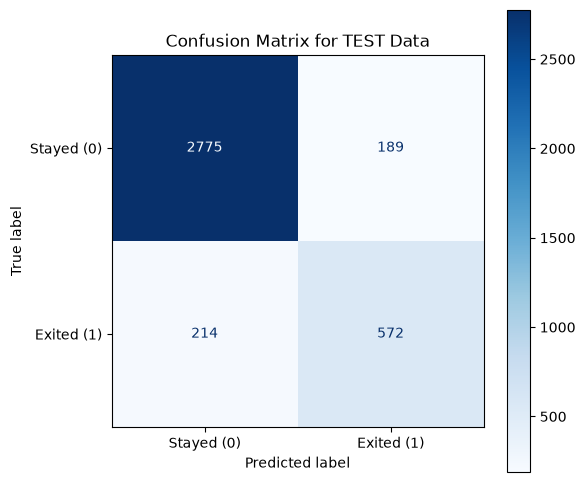

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Հաշվում ենք Confusion Matrix-ը TEST-ի համար
cm_test = confusion_matrix(y_test, best_test_preds)

# 2. Վիզուալիզացիա
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Stayed (0)', 'Exited (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title('Confusion Matrix for TEST Data')
plt.show()

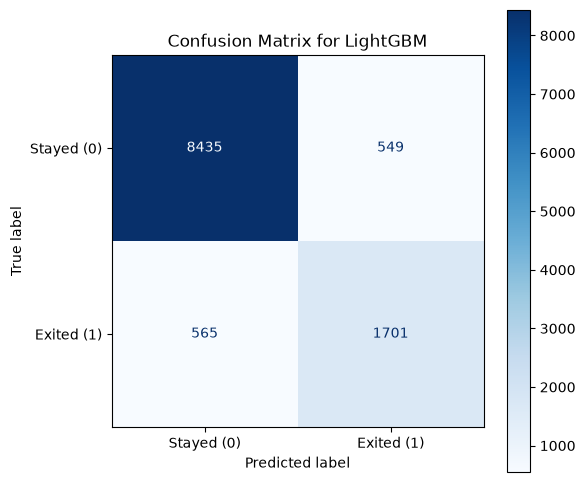

In [85]:
from sklearn.metrics import  ConfusionMatrixDisplay

# 2. Հաշվում ենք Confusion Matrix-ը
cm = confusion_matrix(y_train, best_preds)

# Վիզուալիզացիա
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Exited (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title('Confusion Matrix for LightGBM')
plt.show()

In [86]:
print(classification_report(y_train, best_preds))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      8984
           1       0.76      0.75      0.75      2266

    accuracy                           0.90     11250
   macro avg       0.85      0.84      0.85     11250
weighted avg       0.90      0.90      0.90     11250



In [87]:
print(roc_auc_score(y_train, best_preds))

0.8447766609109537


In [89]:
# Վերցնում ենք դրական դասի (1) հավանականությունները
ensemble_oof_probs = (best_weight_cat * cat_oof + best_w_xgb * xgb_oof)

print(f"Անսամբլի OOF ROC-AUC: {roc_auc_score(y_train, ensemble_oof_probs):.4f}")

Անսամբլի OOF ROC-AUC: 0.9368


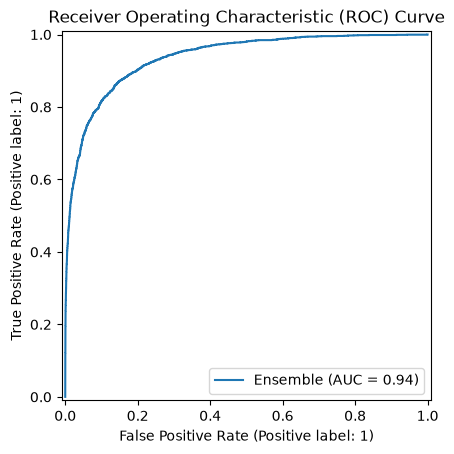

In [90]:
from sklearn.metrics import  RocCurveDisplay
RocCurveDisplay.from_predictions(y_train, ensemble_oof_probs, name="Ensemble",)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

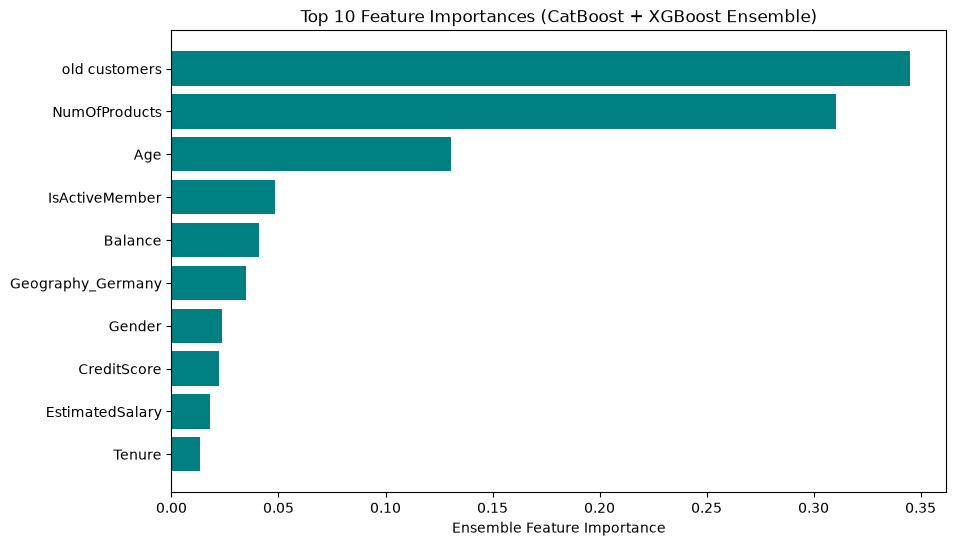

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ստանում ենք յուրաքանչյուր մոդելի ֆիչերների կարևորությունները
xgb_importances = xgb_after_overfitting.feature_importances_
cat_importances = cat_after_overfitting.feature_importances_

# Որպեսզի սանդղակները նույնը լինեն, նորմալացնում ենք (sum = 1)
cat_importances = cat_importances / cat_importances.sum()
xgb_importances = xgb_importances / xgb_importances.sum()

# 2. Միջինացնում ենք անսամբլի կշիռներով
ensemble_importances = (best_weight_cat * cat_importances) + (best_w_xgb * xgb_importances)

# 3. Սարքում ենք DataFrame հարմար նկարելու համար
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': ensemble_importances
}).sort_values(by='Importance', ascending=False)

# 4. Վիզուալիզացիա (Top 10 կամ բոլորը)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1], color='teal')
plt.xlabel('Ensemble Feature Importance')
plt.title('Top 10 Feature Importances (CatBoost + XGBoost Ensemble)')
plt.show()